In [1]:
!pip install pandas scikit-learn xgboost google-cloud-bigquery db-dtypes
!pip install xgboost==1.7.6

In [2]:
from google.cloud import bigquery

client = bigquery.Client(project = "fraudexplanationassistant")

query = """
        select count(*)
        from fraudexplanationassistant.fraud_detection.transactions
        """

query_job = client.query(query)
results = query_job.result()

for row in results:
    print(row)

Row((590540,), {'f0_': 0})


In [3]:
query = """
        select *
        from fraudexplanationassistant.fraud_detection.transactions
        """

df = client.query(query).to_dataframe()

print(f"{df.shape[0]} rows and {df.shape[1]} columns")
print(df['isFraud'].value_counts())

590540 rows and 394 columns
isFraud
0    569877
1     20663
Name: count, dtype: Int64


In [4]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)

In [5]:
cols_to_drop = ['TransactionID', 'TransactionDT']
df.drop(cols_to_drop, axis = 1, inplace = True)

In [6]:
df.head()

,isFraud,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,0,150.0,S,12538,543.0,150.0,mastercard,224.0,debit,337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,50.0,S,13844,583.0,150.0,visa,226.0,credit,330.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,150.0,H,16659,170.0,150.0,visa,226.0,credit,325.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,30.0,S,7648,357.0,150.0,visa,226.0,debit,330.0,...,0.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,50.0,R,10486,514.0,150.0,mastercard,219.0,credit,123.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.dtypes.value_counts()

float64    376
boolean      8
object       6
Int64        2
Name: count, dtype: int64

In [8]:
numerical_cols = []
categorical_cols = []

In [9]:
target_col = 'isFraud'

In [10]:
for col in df.columns:

    if col != target_col:
        missing_cnt = df[col].isna().sum()
        missing_pct = (missing_cnt*100) / len(df)

        if missing_pct > 50:
            df.drop(col, axis = 1, inplace = True)
            print(f"Dropping: {col}")

        elif df[col].dtype in ('Int64', 'float64'):
            mean = round(df[col].mean(), 2)
            df[col] = df[col].fillna(mean)
            print(f"Filled NAs for:{col} with mean: {mean}")
            if col not in numerical_cols:
                numerical_cols.append(col)

        elif df[col].dtype == 'boolean':
            pass

        else:
            mode = df[col].mode()[0]
            df[col] = df[col].fillna(mode)
            print(f"Filled NAs for:{col} with mean: {mode}")
            if col not in categorical_cols:
                categorical_cols.append(col)
    

Filled NAs for:TransactionAmt with mean: 135.03
Filled NAs for:ProductCD with mean: W
Filled NAs for:card1 with mean: 9898.73
Filled NAs for:card2 with mean: 362.56
Filled NAs for:card3 with mean: 153.19
Filled NAs for:card4 with mean: visa
Filled NAs for:card5 with mean: 199.28
Filled NAs for:card6 with mean: debit
Filled NAs for:addr1 with mean: 290.73
Filled NAs for:addr2 with mean: 86.8
Dropping: dist1
Dropping: dist2
Filled NAs for:P_emaildomain with mean: gmail.com
Dropping: R_emaildomain
Filled NAs for:C1 with mean: 14.09
Filled NAs for:C2 with mean: 15.27
Filled NAs for:C3 with mean: 0.01
Filled NAs for:C4 with mean: 4.09
Filled NAs for:C5 with mean: 5.57
Filled NAs for:C6 with mean: 9.07
Filled NAs for:C7 with mean: 2.85
Filled NAs for:C8 with mean: 5.14
Filled NAs for:C9 with mean: 4.48
Filled NAs for:C10 with mean: 5.24
Filled NAs for:C11 with mean: 10.24
Filled NAs for:C12 with mean: 4.08
Filled NAs for:C13 with mean: 32.54
Filled NAs for:C14 with mean: 8.3
Filled NAs for:D

In [11]:
df_original = df.copy()

In [12]:
!pip install scipy

In [13]:
numerical_cols

['TransactionAmt',
 'card1',
 'card2',
 'card3',
 'card5',
 'addr1',
 'addr2',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D10',
 'D11',
 'D15',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V86',
 'V87',
 'V88',
 'V89',
 'V90',
 'V91',
 'V92',
 'V93',
 'V94',
 'V95',
 'V96',
 'V97',

In [14]:
categorical_cols

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M4']

In [15]:
df.shape

(590540, 218)

In [16]:
from scipy.stats import chi2_contingency
import pandas as pd

def chi_square_test(df, categorical_col, target_col = 'isFraud'):

    table = pd.crosstab(df[categorical_col], df[target_col])
    chi_statistic, p_value, dof, expected = chi2_contingency(table)


    print(f"chi_statistic: {chi_statistic:.4f}")
    print(f"p_value: {p_value:.4f}")
    
    if p_value < .05:
        print(f"SIGNIFICANT FEATURE. Keep {categorical_col}")

    else:
        df.drop(categorical_col, axis = 1, inplace = True)
        print(f"NOT SIGNIFICANT FEATURE. Consider dropping {categorical_col}")
        

for categorical_col in categorical_cols:
    chi_square_test(df, categorical_col, target_col = 'isFraud')
    print()

chi_statistic: 16742.1715
p_value: 0.0000
SIGNIFICANT FEATURE. Keep ProductCD

chi_statistic: 365.3347
p_value: 0.0000
SIGNIFICANT FEATURE. Keep card4

chi_statistic: 5966.2866
p_value: 0.0000
SIGNIFICANT FEATURE. Keep card6

chi_statistic: 3308.6232
p_value: 0.0000
SIGNIFICANT FEATURE. Keep P_emaildomain

chi_statistic: 12236.7352
p_value: 0.0000
SIGNIFICANT FEATURE. Keep M4



In [17]:
from scipy.stats import ttest_ind

def ttest(df, numerical_col, target_col = 'isFraud'):

    non_fraud = df[df[target_col] == 0][numerical_col]
    fraud = df[df[target_col] == 1][numerical_col]

    t_test_value, p_value = ttest_ind(non_fraud, fraud)
    
    print(f"t_test_value: {t_test_value:.4f}")
    print(f"p_value: {p_value:.4f}")
    
    if p_value < .05:
        print(f"SIGNIFICANT FEATURE. Keep {numerical_col}")

    else:
        df.drop(numerical_col, axis = 1, inplace = True)
        print(f"NOT SIGNIFICANT FEATURE. Consider dropping {numerical_col}")

for numerical_col in numerical_cols:
    ttest(df, numerical_col, target_col = 'isFraud')
    print()

t_test_value: -8.6994
p_value: 0.0000
SIGNIFICANT FEATURE. Keep TransactionAmt

t_test_value: 10.4828
p_value: 0.0000
SIGNIFICANT FEATURE. Keep card1

t_test_value: -2.5770
p_value: 0.0100
SIGNIFICANT FEATURE. Keep card2

t_test_value: -119.7753
p_value: 0.0000
SIGNIFICANT FEATURE. Keep card3

t_test_value: 25.6890
p_value: 0.0000
SIGNIFICANT FEATURE. Keep card5

t_test_value: -3.4173
p_value: 0.0006
SIGNIFICANT FEATURE. Keep addr1

t_test_value: 18.5803
p_value: 0.0000
SIGNIFICANT FEATURE. Keep addr2

t_test_value: -23.5028
p_value: 0.0000
SIGNIFICANT FEATURE. Keep C1

t_test_value: -28.6290
p_value: 0.0000
SIGNIFICANT FEATURE. Keep C2

t_test_value: 5.2512
p_value: 0.0000
SIGNIFICANT FEATURE. Keep C3

t_test_value: -23.3584
p_value: 0.0000
SIGNIFICANT FEATURE. Keep C4

t_test_value: 23.6445
p_value: 0.0000
SIGNIFICANT FEATURE. Keep C5

t_test_value: -16.0713
p_value: 0.0000
SIGNIFICANT FEATURE. Keep C6

t_test_value: -21.6488
p_value: 0.0000
SIGNIFICANT FEATURE. Keep C7

t_test_value

/opt/conda/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


t_test_value: -0.7851
p_value: 0.4324
NOT SIGNIFICANT FEATURE. Consider dropping V1

t_test_value: -9.2991
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V2

t_test_value: -21.0277
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V3

t_test_value: -5.6857
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V4

t_test_value: -15.8369
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V5

t_test_value: -5.2839
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V6

t_test_value: -9.4524
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V7

t_test_value: -7.3302
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V8

t_test_value: -15.6520
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V9

t_test_value: 31.8122
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V10

t_test_value: 30.2324
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V11

t_test_value: 36.3673
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V12

t_test_value: 31.6995
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V13

t_test_value: -1.6951
p_value: 0.0901
NOT SIGNIFICANT FEATURE. Consider dropping V14

t_test

/opt/conda/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


t_test_value: 0.3808
p_value: 0.7033
NOT SIGNIFICANT FEATURE. Consider dropping V305

t_test_value: 1.4317
p_value: 0.1522
NOT SIGNIFICANT FEATURE. Consider dropping V306

t_test_value: -4.5708
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V307

t_test_value: -2.4999
p_value: 0.0124
SIGNIFICANT FEATURE. Keep V308

t_test_value: -15.5683
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V309

t_test_value: -8.5078
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V310

t_test_value: -0.9991
p_value: 0.3178
NOT SIGNIFICANT FEATURE. Consider dropping V311

t_test_value: -28.8965
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V312

t_test_value: -31.8788
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V313

t_test_value: -29.6020
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V314

t_test_value: -37.1173
p_value: 0.0000
SIGNIFICANT FEATURE. Keep V315

t_test_value: 2.2748
p_value: 0.0229
SIGNIFICANT FEATURE. Keep V316

t_test_value: -3.8497
p_value: 0.0001
SIGNIFICANT FEATURE. Keep V317

t_test_value: -0.7662
p_value: 0.4435

In [18]:
df.shape

(590540, 199)

In [19]:
numerical_cols

['TransactionAmt',
 'card1',
 'card2',
 'card3',
 'card5',
 'addr1',
 'addr2',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D10',
 'D11',
 'D15',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V86',
 'V87',
 'V88',
 'V89',
 'V90',
 'V91',
 'V92',
 'V93',
 'V94',
 'V95',
 'V96',
 'V97',

In [20]:
categorical_cols

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M4']

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [22]:
df.to_csv('cleaned_transactions.csv', index=False)
df_original[['ProductCD', 'P_emaildomain', 'isFraud', 'TransactionAmt']].to_csv('original_categories.csv', index=False)

In [23]:
client = bigquery.Client(project = "fraudexplanationassistant")

cnt_query = """
        SELECT 
        COUNT(*) as total_transactions,
        SUM(isFraud) as total_fraud,
        ROUND(SUM(isFraud) / COUNT(*) * 100, 2) as fraud_rate_pct
        FROM `fraudexplanationassistant.fraud_detection.transactions`
        """

query_job = client.query(cnt_query)
results = query_job.result()

for row in results:
    print(row)


Row((590540, 20663, 3.5), {'total_transactions': 0, 'total_fraud': 1, 'fraud_rate_pct': 2})


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score


X = df.drop(columns = target_col)
y = df[target_col]

X_train, X_val, y_train, y_val = train_test_split(X, y, train_size = .6, random_state = 42, stratify=y)


print(f"X_train_scaled shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print()
print(f"X_val_scaled shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")


X_train_scaled shape: (354324, 198)
y_train shape: (354324,)

X_val_scaled shape: (236216, 198)
y_val shape: (236216,)


In [25]:
from xgboost import XGBClassifier

# 569877/20663 = 27.579586700866283
# sum(negative instances) / sum(positive instances)

model = XGBClassifier(scale_pos_weight = 28)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print(f"accuracy_score: {accuracy_score(y_val, y_pred):.2f}")
print(f"recall_score: {recall_score(y_val, y_pred):.2f}")
print(f"precision_score: {precision_score(y_val, y_pred):.2f}")

accuracy_score: 0.91
recall_score: 0.80
precision_score: 0.26


In [26]:
import joblib

joblib.dump(model, 'xgboost_model.joblib')

['xgboost_model.joblib']

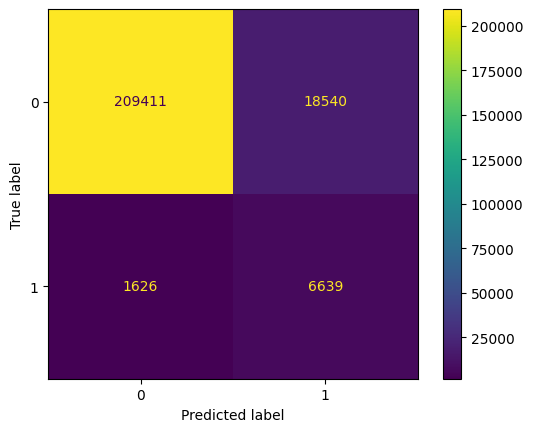

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)
ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.show()

In [28]:
!pip install shap

In [29]:
import shap

booster = model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_train.sample(1000, random_state = 42))

In [30]:
shap_values

array([[ 0.47623837, -0.02272362, -0.07941993, ..., -0.00932624,
         0.24583948,  0.00200241],
       [-0.13756907,  0.02441334, -0.11990462, ...,  0.00585473,
        -0.08511856, -0.00487876],
       [-0.07721015,  0.02418846, -0.16494644, ...,  0.00782969,
         0.13546672, -0.55793667],
       ...,
       [ 0.1309872 , -0.00170413, -0.03667865, ...,  0.00139554,
        -0.08535527, -0.01623904],
       [-0.4134002 ,  0.01143199, -0.04639237, ...,  0.00501852,
        -0.09060392, -0.02661051],
       [-0.17224866,  0.02809035, -0.04945362, ...,  0.003399  ,
        -0.07738609,  0.00100305]], shape=(1000, 198), dtype=float32)

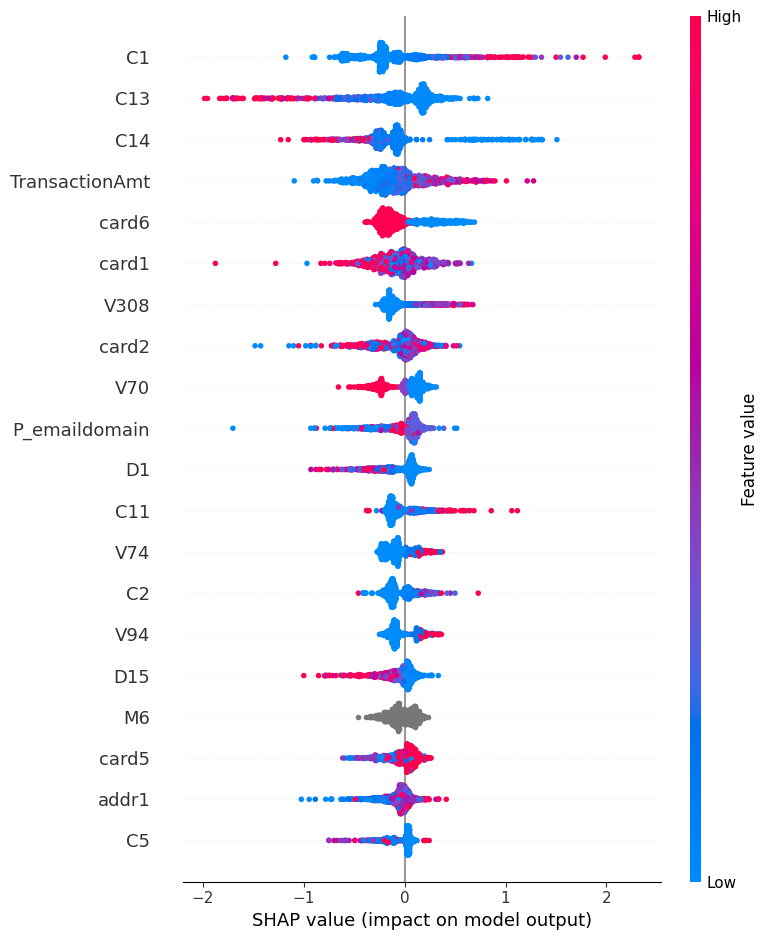

In [31]:
shap.summary_plot(shap_values, X_train.sample(1000, random_state=42))

In [32]:
sample = X_train.sample(1000, random_state = 42)
fraud_indices = sample[y_train[sample.index] == 1].index
fraud_idx = sample.index.get_loc(fraud_indices[0])

single_shap = shap_values[fraud_idx]
feature_names = sample.columns

# getting the top 5 features by absolute SHAP value
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': single_shap
}).reindex(pd.Series(single_shap).abs().sort_values(ascending=False).index)

print(shap_df.head(5))

            feature  shap_value
10    P_emaildomain   -0.655571
1         ProductCD   -0.608842
188            V308    0.393299
11               C1   -0.312985
0    TransactionAmt    0.309470


In [33]:
""" 

C columns — likely count-based features, e.g. how many times a card/address/email has been seen
V columns — Vesta's proprietary engineered features, possibly related to ranking or scoring signals
D columns — likely timedelta features, e.g. days since last transaction


"""

" \n\nC columns — likely count-based features, e.g. how many times a card/address/email has been seen\nV columns — Vesta's proprietary engineered features, possibly related to ranking or scoring signals\nD columns — likely timedelta features, e.g. days since last transaction\n\n\n"

In [34]:
!pip install google-cloud-aiplatform

In [35]:
import vertexai

vertexai.init(project = "fraudexplanationassistant", location="us-central1")

from vertexai.generative_models import GenerativeModel
gemini_model = GenerativeModel('gemini-2.5-flash')

import joblib
model = joblib.load('xgboost_model.joblib')


/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1beta1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1beta1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_supp

In [36]:
fraud_indices = X_val[y_val[X_val.index] == 1].index
# fraud_idx = X_val.index.get_loc(fraud_indices[0])
# fraud_idx = X_val.index.get_loc(fraud_indices[1])
fraud_idx = X_val.index.get_loc(fraud_indices[2])

single_transaction = X_val.iloc[[fraud_idx]]


def single_transaction_analysis(single_transaction):
    feature_names = single_transaction.columns
    fraud_probability = model.predict_proba(single_transaction)[:,1][0]

    shap_values = explainer.shap_values(single_transaction)
    single_shap = shap_values[0]
    
    shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': single_shap
    }).reindex(pd.Series(single_shap).abs().sort_values(ascending=False).index)


    prompt = f"""
    You are a Fraud Explanation Assistant at a financial institution. 
    Your task is to explain to a customer: clearly and calmly as to why their transaction was flagged as potentially unusual.

    Inputs:
    1. Fraud probability: {fraud_probability}
    2. Top 5 contributing factors (SHAP): {shap_df.head(5)}
    3. Transaction details:
        a. Amount: {single_transaction['TransactionAmt'].values[0]}
        b. Product: {df_original.loc[single_transaction.index, 'ProductCD'].values[0]}
        c. Email domain: {df_original.loc[single_transaction.index, 'P_emaildomain'].values[0]}
    
    Guidelines:
    1. Write only 2–3 concise sentences.
    2. Use a calm, reassuring, and non-accusatory tone.
    3. Do NOT say or imply the customer committed fraud.
    4. Avoid technical jargon
    5. Frame the explanation as a routine security precaution.
    6. Reference relevant factors such as transaction size, patterns, timing, or unusual activity if applicable.
    
    Context:
    1. Columns starting with "C" represent transaction count patterns.
    2. Columns starting with "V" represent risk signals.
    3. Columns starting with "D" represent time-related behavior.
    
    Goal:
    You MUST mention the specific transaction amount of {single_transaction['TransactionAmt'].values[0]} 
    and reference the specific risk factors identified above.
    Do not give a generic response.
    """
    response = gemini_model.generate_content(prompt)
    initial_explanation = response.text
    return initial_explanation, prompt
    
initial_explanation, prompt = single_transaction_analysis(single_transaction)
print(initial_explanation)
print()
print(prompt)

Your recent $115.95 transaction was flagged for review because our system detected some unusual patterns in transaction counts and timing. This is a routine security measure taken to protect your account from potential unauthorized activity.


    You are a Fraud Explanation Assistant at a financial institution. 
    Your task is to explain to a customer: clearly and calmly as to why their transaction was flagged as potentially unusual.

    Inputs:
    1. Fraud probability: 0.7841527462005615
    2. Top 5 contributing factors (SHAP):    feature  shap_value
11      C1    1.288077
23     C13   -1.002924
21     C11    0.524759
12      C2    0.494496
30     D11    0.460609
    3. Transaction details:
        a. Amount: 115.95
        b. Product: W
        c. Email domain: yahoo.com
    
    Guidelines:
    1. Write only 2–3 concise sentences.
    2. Use a calm, reassuring, and non-accusatory tone.
    3. Do NOT say or imply the customer committed fraud.
    4. Avoid technical jargon
    5

In [37]:
def dispute_chat(single_transaction, initial_explanation, prompt):

    chat = gemini_model.start_chat()
    response = chat.send_message(prompt)
    print(f"Assistant: {response.text}")
    
    while True:
        user = input("You: ")
        if user == 'exit':
            break
        
        response = chat.send_message(user)
        print(f"Assistant: {response.text}")
    
dispute_chat(single_transaction, initial_explanation, prompt)
"""
"I did make this transaction, it was me"
"""

Assistant: Your recent transaction for 115.95 was flagged by our system for review as a standard security precaution. This is due to certain unusual transaction patterns and the timing associated with the purchase.


You:  I did make this transaction, it was me


Assistant: Thank you for confirming that you made this transaction. Our system flagged it as a routine security check, and we appreciate you helping us verify its legitimacy. Your transaction can now proceed as planned.


You:  break


Assistant: Understood. Is there anything else I can help you with today, or would you like to start a new query?


You:  exit


'\n\n"I did make this transaction, it was me"\n"I did not make this transaction, please help"\n"Can you explain more about why it was flagged?"\n\n'

In [38]:
def dispute_chat(single_transaction, initial_explanation, prompt):

    chat = gemini_model.start_chat()
    response = chat.send_message(prompt)
    print(f"Assistant: {response.text}")
    
    while True:
        user = input("You: ")
        if user == 'exit':
            break
        
        response = chat.send_message(user)
        print(f"Assistant: {response.text}")
    
dispute_chat(single_transaction, initial_explanation, prompt)
"""
"I did not make this transaction, please help"
"""

Assistant: For your protection, your recent transaction of $115.95 triggered a routine security alert. This was primarily due to some unusual patterns in your transaction history and timing compared to your typical activity.


You:  I did not make this transaction, please help


Assistant: I understand you did not make this transaction. To help you secure your account and investigate this $115.95 charge, please contact our fraud prevention team immediately, as they are equipped to assist you further.


You:  exit


'\n\n"I did make this transaction, it was me"\n"I did not make this transaction, please help"\n"Can you explain more about why it was flagged?"\n\n'

In [39]:
def dispute_chat(single_transaction, initial_explanation, prompt):

    chat = gemini_model.start_chat()
    response = chat.send_message(prompt)
    print(f"Assistant: {response.text}")
    
    while True:
        user = input("You: ")
        if user == 'exit':
            break
        
        response = chat.send_message(user)
        print(f"Assistant: {response.text}")
    
dispute_chat(single_transaction, initial_explanation, prompt)
"""
Can you explain more about why it was flagged?
"""

Assistant: Your recent transaction of $115.95 was flagged for a routine security review due to some unusual transaction count patterns and atypical timing. This is a standard precaution to ensure the security of your account.


You:  Can you explain more about why it was flagged?


Assistant: For your $115.95 transaction, our system detected a combination of unusual transaction count patterns, indicating a higher frequency of certain activities than typically observed, and some atypical timing behavior. This led to a routine security flag to ensure your account's protection.


You:  exit


'\nCan you explain more about why it was flagged?\n'